In [1]:
!pip install matplotlib

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [3]:
import matplotlib.font_manager as fm
import platform

font_path="C:/Windows/Fonts/malgun.ttf"
font_prop=fm.FontProperties(fname=font_path)

In [4]:
df_sample=pd.read_csv("./data/network_data.csv")
df_sample.head()

,고객ID,고객이름,동반인ID,주문메뉴
0,C0116,고객116,NaN,"['쫄면', '칼국수']"
1,C0169,고객169,NaN,"['순두부찌개', '된장찌개', '불고기']"
2,C0086,고객86,C0153,['쫄면']
3,C0104,고객104,C0163,"['순두부찌개', '된장찌개', '비빔밥']"
4,C0126,고객126,NaN,"['비빔밥', '김치찌개']"


In [5]:
customer_dict=dict(zip(df_sample['고객ID'], df_sample['고객이름']))
customer_dict

{'C0116': '고객116',
 'C0169': '고객169',
 'C0086': '고객86',
 'C0104': '고객104',
 'C0126': '고객126',
 'C0184': '고객184',
 'C0181': '고객181',
 'C0154': '고객154',
 'C0081': '고객81',
 'C0199': '고객199',
 'C0149': '고객149',
 'C0058': '고객58',
 'C0042': '고객42',
 'C0187': '고객187',
 'C0176': '고객176',
 'C0107': '고객107',
 'C0177': '고객177',
 'C0027': '고객27',
 'C0144': '고객144',
 'C0072': '고객72',
 'C0123': '고객123',
 'C0132': '고객132',
 'C0005': '고객5',
 'C0140': '고객140',
 'C0048': '고객48',
 'C0049': '고객49',
 'C0114': '고객114',
 'C0138': '고객138',
 'C0045': '고객45',
 'C0031': '고객31',
 'C0078': '고객78',
 'C0164': '고객164',
 'C0047': '고객47',
 'C0028': '고객28',
 'C0089': '고객89',
 'C0119': '고객119',
 'C0170': '고객170',
 'C0150': '고객150',
 'C0004': '고객4',
 'C0093': '고객93',
 'C0069': '고객69',
 'C0180': '고객180',
 'C0143': '고객143',
 'C0021': '고객21',
 'C0030': '고객30',
 'C0200': '고객200',
 'C0139': '고객139',
 'C0092': '고객92',
 'C0159': '고객159',
 'C0088': '고객88',
 'C0195': '고객195',
 'C0076': '고객76',
 'C0053': '고객53',
 'C0033': '고객33',
 

In [6]:
# 고객 네트워크 그래프 생성
G=nx.Graph()

for _, row in df_sample.iterrows():
    cust_id=row['고객ID']
    cust_name=row['고객이름']
    cust_label=f"{cust_name}({cust_id})"
    
    companion_id=row['동반인ID']
    if pd.notnull(companion_id):
        companion_name=customer_dict.get(companion_id, companion_id)
        companion_label=f"{companion_name}({companion_id})"
        
        G.add_node(cust_label)
        G.add_node(companion_label)
        G.add_edge(cust_label, companion_label)
    
    

In [7]:
degree_centrality=nx.degree_centrality(G)
betweenness_centrality=nx.betweenness_centrality(G)
closeness_centrality=nx.closeness_centrality(G)

In [8]:
sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('고객106(C0106)', 0.05154639175257732),
 ('고객133(C0133)', 0.04639175257731959),
 ('고객153(C0153)', 0.041237113402061855),
 ('고객163(C0163)', 0.041237113402061855),
 ('고객100(C0100)', 0.041237113402061855),
 ('고객114(C0114)', 0.041237113402061855),
 ('고객195(C0195)', 0.041237113402061855),
 ('고객24(C0024)', 0.03608247422680412),
 ('고객170(C0170)', 0.03608247422680412),
 ('고객183(C0183)', 0.03608247422680412)]

In [10]:
top_k=10
top_degree=sorted(degree_centrality.items(), key=lambda x:x[1], reverse=True)[:top_k]

result=[]
for node, degree in top_degree:
    result.append({
        '고객이름(고객ID)': node,
        '연결중심성(Degree)': round(degree, 4),
        '매개중심성(Betweenness)': round(betweenness_centrality.get(node, 0),4),
        '근접중심성(Closeness)': round(closeness_centrality.get(node,0), 4)
    })
    
df_result=pd.DataFrame(result)
df_result

,고객이름(고객ID),연결중심성(Degree),매개중심성(Betweenness),근접중심성(Closeness)
0,고객106(C0106),0.0515,0.0713,0.3050
1,고객133(C0133),0.0464,0.0645,0.3065
2,고객153(C0153),0.0412,0.0440,0.2840
3,고객163(C0163),0.0412,0.0366,0.2904
4,고객100(C0100),0.0412,0.0531,0.2953
5,고객114(C0114),0.0412,0.0517,0.2900
6,고객195(C0195),0.0412,0.0707,0.3031
7,고객24(C0024),0.0361,0.0412,0.2866
8,고객170(C0170),0.0361,0.0331,0.2771
9,고객183(C0183),0.0361,0.0375,0.2870


ValueError: <function plasma at 0x7fed43eb9040> is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'co

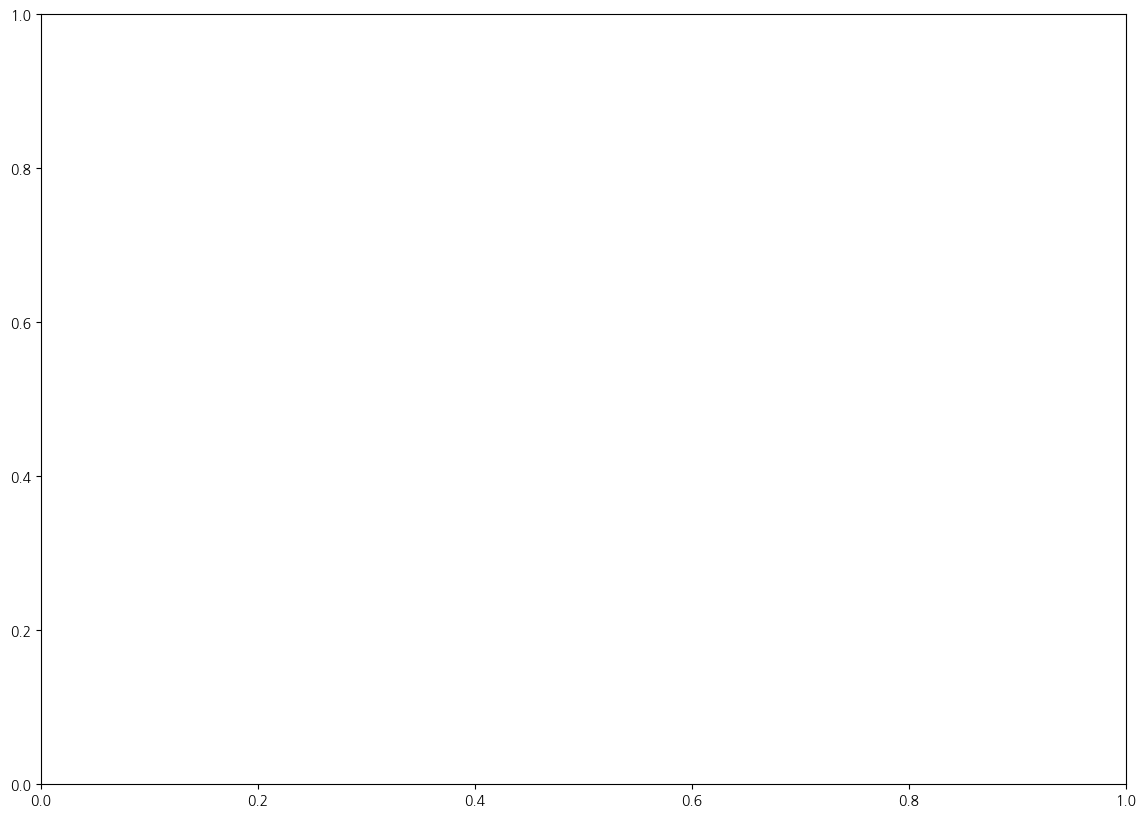

In [14]:
plt.rcParams['axes.unicode_minus']=False

node_colors=[degree_centrality.get(node, 0) for node in G.nodes]
node_sizes=[2000*degree_centrality.get(node, 0)+100 for node in G.nodes]

pos=nx.spring_layout(G, seed=42, k=0.5)

plt.figure(figsize=(14, 10))
nodes=nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, cmap=plt.plasma)

nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=10, font_family=font_prop.get_name())
plt.colorbar(nodes, label='연결중심성')
plt.title('고객 동반방문 네트워크 중심성 시각화', fontproperties=font_prop, fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()